In [1]:
from google.colab import files
uploaded = files.upload()


Saving instagram_influencers_dataset.csv to instagram_influencers_dataset (1).csv


In [2]:
import pandas as pd

df = pd.read_csv("instagram_influencers_dataset.csv")
df.head()


,username,followers,following,total_posts,avg_likes,avg_comments,category,country,engagement_rate
0,synthetic_influencer_20,1086282,1949,299,29761,1261,Food,Canada,2.86
1,synthetic_influencer_23,1040351,951,2872,12942,780,Fashion,Canada,1.32
2,synthetic_influencer_54,313313,317,1012,11324,750,Food,India,3.85
3,synthetic_influencer_43,4377702,1062,2313,96949,7564,Travel,USA,2.39
4,synthetic_influencer_7,4426425,90,1890,91045,2582,Fashion,USA,2.12


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

X = df[['followers', 'following', 'total_posts', 'category']]
y = df['engagement_rate']

# Encode categorical column
ct = ColumnTransformer([
    ('onehot', OneHotEncoder(), ['category'])
], remainder='passthrough')

X_encoded = ct.fit_transform(X)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


In [4]:
# Remove rows where target is NaN
df = df.dropna(subset=['engagement_rate'])

# Features and target again
X = df[['followers', 'following', 'total_posts', 'category']]
y = df['engagement_rate']


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

ct = ColumnTransformer([
    ('onehot', OneHotEncoder(), ['category'])
], remainder='passthrough')

X_encoded = ct.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("R² score:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))


R² score: -0.3508193578831149
RMSE: 1.3771284753064976


In [7]:
import joblib

# Save RandomForest model
joblib.dump(rf_model, 'rf_model.pkl')

# Save ColumnTransformer
joblib.dump(ct, 'ct.pkl')


['ct.pkl']

In [15]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Load model and encoder
rf_model = joblib.load("rf_model.pkl")
ct = joblib.load("ct.pkl")

st.title("Instagram Influencer Analysis")

# Input influencer data
followers = st.number_input("Followers", min_value=0)
following = st.number_input("Following", min_value=0)
total_posts = st.number_input("Total Posts", min_value=0)
category = st.selectbox("Category", ['Fashion','Fitness','Tech','Food','Travel'])

# Predict button
if st.button("Predict Engagement Rate"):
    input_df = pd.DataFrame({
        'followers':[followers],
        'following':[following],
        'total_posts':[total_posts],
        'category':[category]
    })
    input_encoded = ct.transform(input_df)
    prediction = rf_model.predict(input_encoded)
    st.success(f"Predicted Engagement Rate: {prediction[0]:.2f}%")

# Optional: show EDA plot
st.subheader("Average Engagement Rate by Category")
dataset = pd.read_csv("instagram_influencers_dataset_clean.csv")
st.bar_chart(dataset.groupby('category')['engagement_rate'].mean())


Overwriting app.py


username           0
followers          0
following          0
total_posts        0
avg_likes          0
avg_comments       0
category           0
country            0
engagement_rate    0
dtype: int64


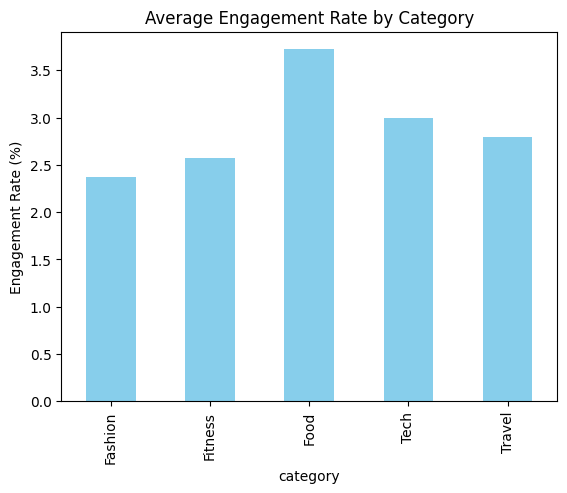

   category  followers  total_posts  engagement_rate
53     Food    3884594         1617             5.17
5    Travel    4712160         2262             5.10
15  Fitness    3496201         2315             5.09
26     Tech    4737613         1875             4.91
32     Tech    4772446         2320             4.73


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
dataset = pd.read_csv("instagram_influencers_dataset_clean.csv")

# Check for missing values
print(dataset.isna().sum())

# Drop NaNs in target
dataset = dataset.dropna(subset=['engagement_rate'])

# Average engagement by category
dataset.groupby('category')['engagement_rate'].mean().plot(kind='bar', color='skyblue')
plt.title("Average Engagement Rate by Category")
plt.ylabel("Engagement Rate (%)")
plt.show()

# Top 5 influencers
top5 = dataset.sort_values(by='engagement_rate', ascending=False).head(5)
print(top5[['category','followers','total_posts','engagement_rate']])


In [17]:
dataset.to_csv("instagram_influencers_dataset_clean.csv", index=False)


In [9]:
!pip install scikit-learn==1.7.2
